In [1]:
# =========================
# 0. Imports
# =========================
import json
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score, hamming_loss, classification_report
from sklearn.metrics import multilabel_confusion_matrix

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)

from datasets import Dataset

# =========================
# 1. Load Data
# =========================
with open(r"C:\Users\m\Downloads\projects2.json", encoding="utf-8") as f:
    data = json.load(f)

rows = []
for project, info in data.items():
    for task in info.get("tasks", []):
        rows.append({
            "text": task.get("task_description", ""),
            "tracks": task.get("track", [])
        })

df = pd.DataFrame(rows)

# =========================
# 2. Normalize Tracks
# =========================
TRACK_KEYWORDS = {
    "Backend": ["backend"],
    "Frontend": ["frontend"],
    "Database": ["database"],
    "ML/AI": ["ml", "ai"]
}

def normalize_tracks(track):
    found = set()
    text = " ".join(track).lower() if isinstance(track, list) else str(track).lower()
    for main, kws in TRACK_KEYWORDS.items():
        if any(kw in text for kw in kws):
            found.add(main)
    return list(found)

df["tracks"] = df["tracks"].apply(normalize_tracks)
df = df[df["tracks"].map(len) > 0].reset_index(drop=True)

# =========================
# 3. Encode Labels
# =========================
mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(df["tracks"])
print("Tracks:", mlb.classes_)

# =========================
# 4. Train / Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    df["text"].tolist(),
    Y,
    test_size=0.2,
    random_state=42
)

# =========================
# 5. Tokenization
# =========================
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_ds = Dataset.from_dict({"text": X_train, "labels": y_train})
test_ds  = Dataset.from_dict({"text": X_test,  "labels": y_test})

train_ds = train_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# =========================
# 6. Class Weights
# =========================
label_freq = y_train.sum(axis=0)
pos_weight = (len(y_train) - label_freq) / label_freq
pos_weight = torch.tensor(pos_weight, dtype=torch.float)

# =========================
# 7. Model
# =========================
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(mlb.classes_),
    problem_type="multi_label_classification"
)

# =========================
# 8. Custom Trainer
# =========================
class MultiLabelTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels").float()
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(logits.device))
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

# =========================
# 9. Training Arguments
# =========================
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    use_cpu=True,
    logging_steps=50
)

trainer = MultiLabelTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds
)

# =========================
# 10. Train
# =========================
trainer.train()

# =========================
# 11. Threshold Tuning
# =========================
preds = trainer.predict(test_ds)
logits = preds.predictions
labels = preds.label_ids
probs = torch.sigmoid(torch.tensor(logits)).numpy()

FINAL_THRESHOLDS = {}
for i, label in enumerate(mlb.classes_):
    best_f1, best_t = 0, 0.5
    for t in np.arange(0.25, 0.75, 0.05):
        y_pred = (probs[:, i] >= t).astype(int)
        f1 = f1_score(labels[:, i], y_pred)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    FINAL_THRESHOLDS[label] = round(best_t, 2)

print("Final Thresholds:", FINAL_THRESHOLDS)

# =========================
# 12. Save Model
# =========================
SAVE_PATH = "./task_track_modellllll2"
model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

meta = {
    "classes": mlb.classes_.tolist(),
    "thresholds": FINAL_THRESHOLDS
}

with open(f"{SAVE_PATH}/meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("✅ Model saved successfully")

Tracks: ['Backend' 'Database' 'Frontend' 'ML/AI']


Map:   0%|          | 0/690 [00:00<?, ? examples/s]

Map:   0%|          | 0/173 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
50,0.887889
100,0.692421
150,0.550707
200,0.424180
250,0.368026
300,0.293289
350,0.257868
400,0.240858


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final Thresholds: {'Backend': np.float64(0.4), 'Database': np.float64(0.55), 'Frontend': np.float64(0.6), 'ML/AI': np.float64(0.4)}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved successfully


In [2]:
import json
import torch
import numpy as np
from transformers import BertTokenizer, BertForSequenceClassification

MODEL_PATH = "D:/FCAIH/Year 4/GP/TrackModel"

tokenizer = BertTokenizer.from_pretrained(MODEL_PATH)
model = BertForSequenceClassification.from_pretrained(MODEL_PATH)
model.eval()

with open(f"{MODEL_PATH}/meta.json") as f:
    meta = json.load(f)

CLASSES = meta["classes"]
THRESHOLDS = meta["thresholds"]

# =========================
# Smart Predict (Normalized)
# =========================
def predict_task(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.sigmoid(logits)[0].numpy()

    text_lower = text.lower()

    KEYWORDS = {
        "Backend": ["api", "service", "endpoint", "rest", "authentication"],
        "Frontend": ["frontend", "ui", "ux", "react", "angular", "css", "html","Report"],
        "Database": ["database", "sql", "schema", "table", "query", "postgres","relational"],
        "ML/AI": ["ml", "machine learning", "model", "regression", "classification", "accuracy", "rmse"],
    
    }

    raw_scores = {}

    # Keyword boost
    for i, label in enumerate(CLASSES):
        score = probs[i]
        if any(k in text_lower for k in KEYWORDS.get(label, [])):
            score *= 1.1
        raw_scores[label] = float(score)

    # Apply thresholds
    filtered = {
        label: score
        for label, score in raw_scores.items()
        if score >= THRESHOLDS[label]
    }

    if not filtered:
        best_label = CLASSES[np.argmax(probs)]
        filtered[best_label] = float(np.max(probs))

    # Conflict handling
    if "ML/AI" in filtered and "Backend" in filtered:
        if filtered["ML/AI"] > 0.7:
            filtered["Backend"] *= 0.6

    if "Database" in filtered and "Backend" in filtered:
        if filtered["Database"] > 0.7:
            filtered["Backend"] *= 0.7

    # Normalize weights (sum = 1)
    total = sum(filtered.values())
    normalized = {
        label: round(score / total, 3)
        for label, score in filtered.items()
    }

    return sorted(normalized.items(), key=lambda x: -x[1])

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [3]:
def predict_raw(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.sigmoid(logits)[0].numpy()

    labels_pred = [0] * len(CLASSES)

    for i, label in enumerate(CLASSES):
        if probs[i] >= THRESHOLDS[label]:
            labels_pred[i] = 1

    return labels_pred

In [4]:
def evaluate_model():
    y_pred = []

    for text in X_test:
        y_pred.append(predict_raw(text))

    y_pred = np.array(y_pred)

    print("\n=== PURE MODEL EVALUATION ===")
    print("Hamming Loss:", round(hamming_loss(y_test, y_pred),3))
    print("Micro F1:", round(f1_score(y_test, y_pred, average='micro'),3))
    print("Macro F1:", round(f1_score(y_test, y_pred, average='macro'),3))
    print("\nClassification Report:\n",
          classification_report(y_test, y_pred, target_names=CLASSES))

In [5]:
evaluate_model()


=== PURE MODEL EVALUATION ===
Hamming Loss: 0.084
Micro F1: 0.879
Macro F1: 0.871

Classification Report:
               precision    recall  f1-score   support

     Backend       0.89      0.96      0.92       113
    Database       0.85      1.00      0.92        23
    Frontend       0.69      0.90      0.78        49
       ML/AI       0.81      0.92      0.86        37

   micro avg       0.82      0.95      0.88       222
   macro avg       0.81      0.95      0.87       222
weighted avg       0.83      0.95      0.88       222
 samples avg       0.85      0.94      0.88       222



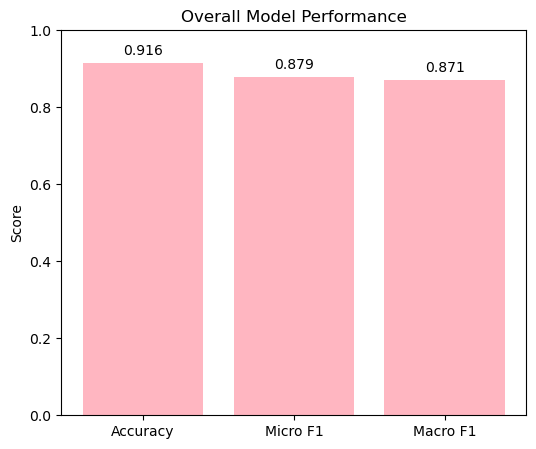

In [16]:
# Chart 2: Overall Performance
# =========================

metrics = ["Micro F1", "Macro F1", "Accuracy"]
scores = [0.879, 0.871, 1 - 0.084]

# Sort DESC
sorted_data = sorted(zip(scores, metrics), reverse=True)
scores_sorted, metrics_sorted = zip(*sorted_data)

plt.figure(figsize=(6,5))
bars = plt.bar(metrics_sorted, scores_sorted, color='lightpink')

plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Overall Model Performance")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.3f}",
        ha='center'
    )

plt.show()

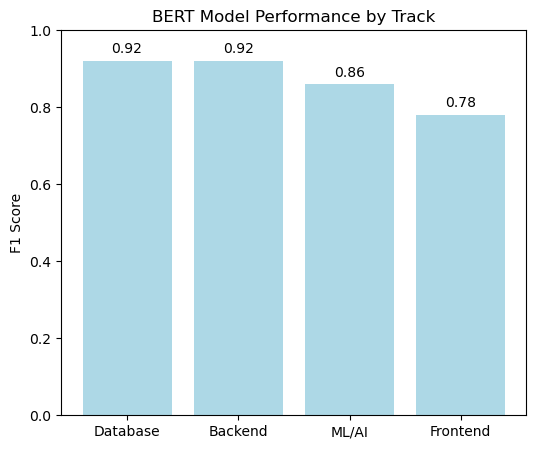

In [17]:
# Chart 1: F1 Score by Track
# =========================

tracks = ["Backend", "Database", "Frontend", "ML/AI"]
f1_scores = [0.92, 0.92, 0.78, 0.86]

# Sort DESC (from high to low)
sorted_data = sorted(zip(f1_scores, tracks), reverse=True)
f1_scores_sorted, tracks_sorted = zip(*sorted_data)

plt.figure(figsize=(6,5))
bars = plt.bar(tracks_sorted, f1_scores_sorted, color='lightblue')

plt.ylim(0,1)
plt.ylabel("F1 Score")
plt.title("BERT Model Performance by Track")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.02,
        f"{height:.2f}",
        ha='center'
    )

plt.show()

